# Libs

In [ ]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")

In [ ]:
# datos pib y luz

url = 'drive url'
output = 'q_data.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1-jIhgKchXjhlB6oWZ_M-ut0wJnck0ZCr
To: /content/q_data.csv
100%|██████████| 161k/161k [00:00<00:00, 41.4MB/s]


'q_data.csv'

In [ ]:
quarterly_df = pd.read_csv(output)
print(quarterly_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   municipio               656 non-null    object 
 1   quarter                 656 non-null    object 
 2   pib_mun                 656 non-null    float64
 3   total_pixeles_median    656 non-null    float64
 4   suma_rad_trend_sum      656 non-null    float64
 5   suma_rad_trend_mean     656 non-null    float64
 6   suma_rad_trend_std      656 non-null    float64
 7   suma_rad_trend_median   656 non-null    float64
 8   media_rad_trend_mean    656 non-null    float64
 9   std_rad_trend_mean      656 non-null    float64
 10  max_rad_trend_max       656 non-null    float64
 11  min_rad_trend_min       656 non-null    float64
 12  p25_rad_trend_mean      656 non-null    float64
 13  mediana_rad_trend_mean  656 non-null    float64
 14  p75_rad_trend_mean      656 non-null    fl

In [ ]:
quarterly_df.columns

Index(['municipio', 'quarter', 'pib_mun', 'total_pixeles_median',
       'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean'],
      dtype='object')

In [ ]:
def preprocess(dataframe, log = True,  encode = True, n_lags= 2, ):
  df = dataframe.copy()

  df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
  df['fecha'] = df['quarter'].dt.to_timestamp(how='end')
  df['year'] = df['fecha'].dt.year

  log_cols =  ['pib_mun', 'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean']

  if log:
    df[log_cols] = df[log_cols].replace(0, 1e-5)
    df[log_cols]= df[log_cols].apply(np.log)

  df = df.sort_values(['municipio', 'quarter'])

  col = 'suma_rad_trend_median'

  if encode:
    df = pd.get_dummies(
        df,
        columns= ['municipio'],
        drop_first=False,
        dtype=int
    )

    df = df.dropna()

  return df

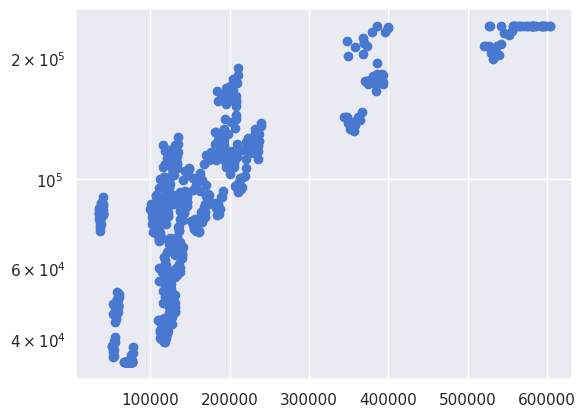

In [ ]:
plt.scatter(quarterly_df.pib_mun,quarterly_df.suma_rad_trend_mean)
plt.yscale('log')

In [ ]:
quarterly_df_coded = preprocess(quarterly_df,log = True, encode = True)
quarterly_df_coded.columns

Index(['quarter', 'pib_mun', 'total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'fecha', 'year', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco'],
      dtype='object')

In [ ]:
# no geo effects no time
features = ['total_pixeles_median',
       'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean']
target = 'pib_mun'


X = quarterly_df_coded[features]
y = quarterly_df_coded[target]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled=  sm.add_constant(X_scaled)

# Prueba de linealidad

In [ ]:
# regresion
model_reg = sm.OLS(y,X_scaled).fit()
print(model_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     555.4
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:01:43   Log-Likelihood:                 163.15
No. Observations:                 656   AIC:                            -300.3
Df Residuals:                     643   BIC:                            -242.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.8442      0.007   1591.696      0.0

Notas:
* Cond No: multicolinealidad fuerte entre variables.
* Durbin-Watson muy bajo, autocorrelación positiva entre los residuos (tiene sentido, porque es una serie temporal). Los errores no son independientes entre si
* Omnibus y Prob JB inidcan que los residuos no siguen distribucion normal
* kurtosis y skwe alto, no siguen dist normal

**Test RESET**

$H0: $ el modelo sin términos de order mayor es correcto


In [ ]:
reset_test = linear_reset(model_reg, power=2, use_f=True)
print(reset_test)

<F test: F=2.005684161290501, p=0.15719556629837755, df_denom=642, df_num=1>


El modelo sin terminos de orden mayor es mejor que el de orden 2

In [ ]:
residuals = model_reg.resid
print("Sum of residuals:", round(residuals.sum(),5))
print("Mean of residuals:", round(residuals.mean(),5))


Sum of residuals: -0.0
Mean of residuals: -0.0



Test de Shapiro-Wilk:
Estadístico: 0.9898
p-value: 0.000156
H0: Los residuos son normales
Si p < 0.05 → Rechazamos normalidad


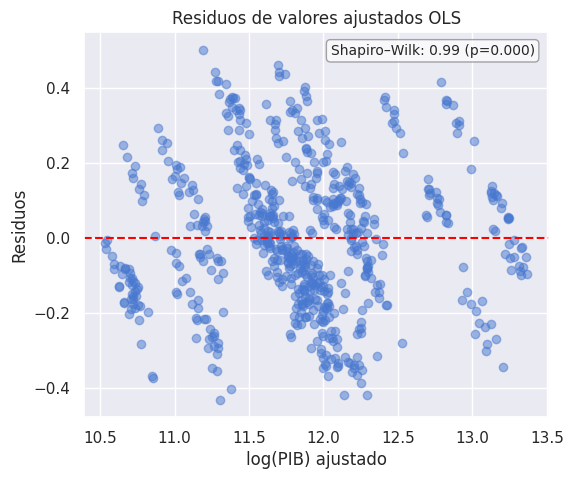

In [ ]:
residuals = model_reg.resid
plt.figure(figsize=(6,5))
plt.scatter(model_reg.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados OLS")



stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"H0: Los residuos son normales")
print(f"Si p < 0.05 → Rechazamos normalidad")

plt.annotate(
    f"Shapiro–Wilk: {stat:.2f} (p={p_value:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.show()


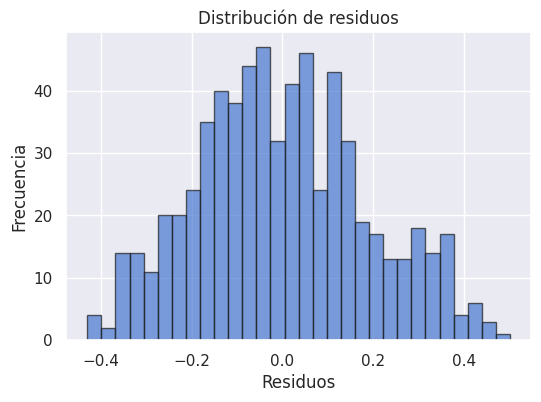

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.show()


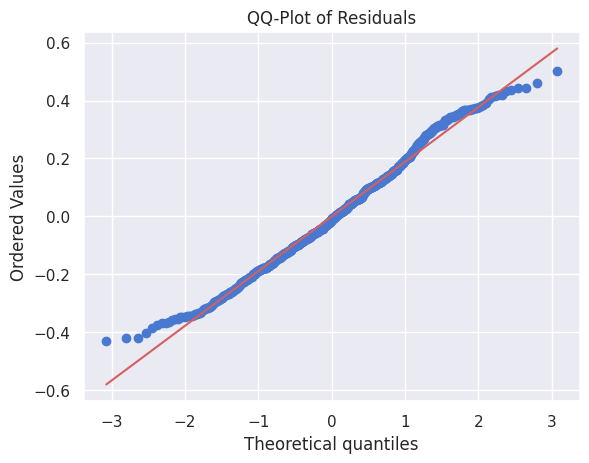

In [ ]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

**ACF**


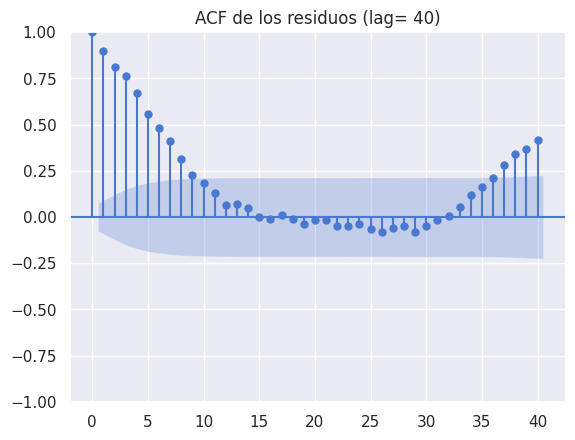

In [ ]:

from statsmodels.graphics.tsaplots import plot_acf
lag = 40
plot_acf(residuals, lags=lag)
plt.title(f"ACF de los residuos (lag= {lag})")
plt.show()


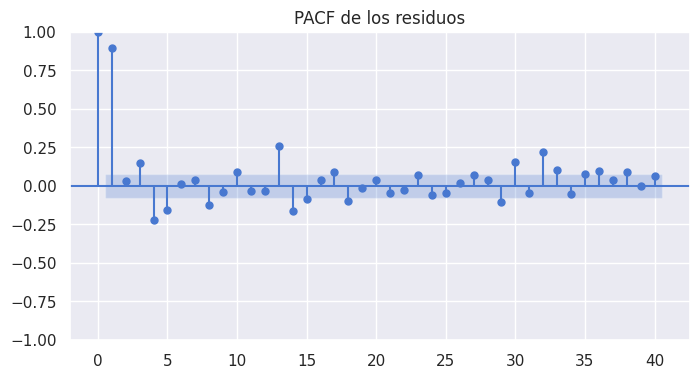

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

# PACF
plt.figure(figsize=(8,4))
plot_pacf(residuals, lags=40, method='ywm', ax=plt.gca())
plt.title("PACF de los residuos")
plt.show()

Ambos sugieren dependencias a largo plazo en los datos que no captura el model, el segundo indica un AR(2)

In [ ]:
X_train_ols = sm.add_constant(X_scaled)
ols_model_robust = sm.OLS(y, X_train_ols).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 4}  # Usar 4 para datos trimestrales
)
print(ols_model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     248.1
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          5.71e-232
Time:                        23:02:23   Log-Likelihood:                 163.15
No. Observations:                 656   AIC:                            -300.3
Df Residuals:                     643   BIC:                            -242.0
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.8442      0.015    776.705      0.0

In [ ]:
import statsmodels.formula.api as smf
# no geo effects
formula = """
pib_mun ~
    total_pixeles_median +
    suma_rad_trend_sum +
    suma_rad_trend_mean +
    suma_rad_trend_std +
    suma_rad_trend_median +
    media_rad_trend_mean +
    std_rad_trend_mean +
    max_rad_trend_max +
    min_rad_trend_min +
    p25_rad_trend_mean +
    mediana_rad_trend_mean +
    p75_rad_trend_mean +
    C(year)
"""

# Fit the OLS model with fixed year effects
model_time = smf.ols(formula=formula, data=quarterly_df_coded).fit()

# Show results
print(model_time.summary())

                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     552.4
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:35:43   Log-Likelihood:                 366.13
No. Observations:                 656   AIC:                            -684.3
Df Residuals:                     632   BIC:                            -576.6
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -2


Test de Shapiro-Wilk:
Estadístico: 0.9954
p-value: 0.045972
H0: Los residuos son normales
Si p < 0.05 → Rechazamos normalidad


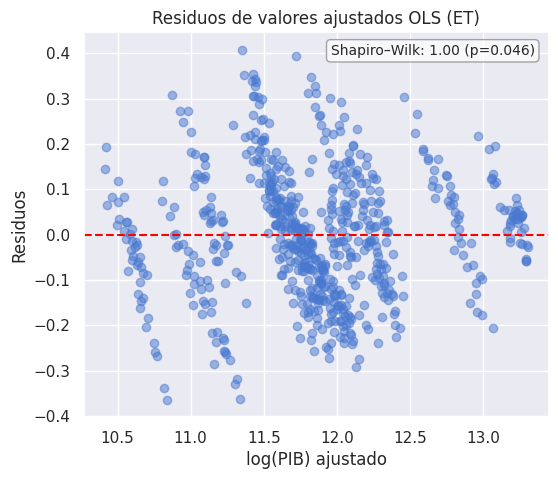

In [ ]:

residuals = model_time.resid

stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"H0: Los residuos son normales")
print(f"Si p < 0.05 → Rechazamos normalidad")


plt.figure(figsize=(6,5))
plt.scatter(model_time.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados OLS (ET)")


plt.annotate(
    f"Shapiro–Wilk: {stat:.2f} (p={p_value:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.show()


In [ ]:
# geo no time
features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco']
target = 'pib_mun'


X = quarterly_df_coded[features]
y = quarterly_df_coded[target]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled=  sm.add_constant(X_scaled)

model_geo = sm.OLS(y,X_scaled).fit()
print(model_geo.summary())

                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     9057.
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:03:35   Log-Likelihood:                 1310.3
No. Observations:                 656   AIC:                            -2567.
Df Residuals:                     629   BIC:                            -2445.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.8442      0.001   9047.457      0.0


Test de Shapiro-Wilk:
Estadístico: 0.9902
p-value: 0.000236
H0: Los residuos son normales
Si p < 0.05 → Rechazamos normalidad


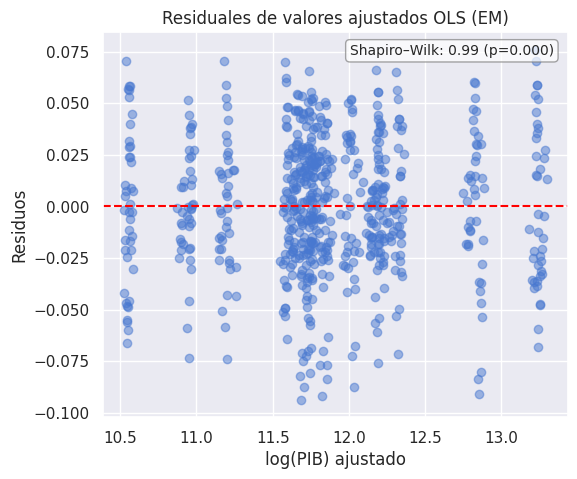

In [ ]:
residuals = model_geo.resid
plt.figure(figsize=(6,5))
plt.scatter(model_geo.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuales de valores ajustados OLS (EM)")


stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"H0: Los residuos son normales")
print(f"Si p < 0.05 → Rechazamos normalidad")

plt.annotate(
    f"Shapiro–Wilk: {stat:.2f} (p={p_value:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.show()

In [ ]:
# geo y time
features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean',
       'municipio_alvaro obregon', 'municipio_azcapotzalco',
       'municipio_benito juarez', 'municipio_coyoacan',
       'municipio_cuajimalpa de morelos', 'municipio_cuauhtemoc',
       'municipio_gustavo a. madero', 'municipio_iztacalco',
       'municipio_iztapalapa', 'municipio_la magdalena contreras',
       'municipio_miguel hidalgo', 'municipio_milpa alta', 'municipio_tlahuac',
       'municipio_tlalpan', 'municipio_venustiano carranza',
       'municipio_xochimilco'
]
target = 'pib_mun'

X = quarterly_df_coded[features]

year_dummies = pd.get_dummies(quarterly_df_coded['year'], prefix='year', drop_first=True)


X = pd.concat([X, year_dummies], axis=1)

y = quarterly_df_coded[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = sm.add_constant(X_scaled)

model_geo_time = sm.OLS(y, X_scaled).fit()
print(model_geo_time.summary())


                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.581e+05
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:39:03   Log-Likelihood:                 2368.9
No. Observations:                 656   AIC:                            -4662.
Df Residuals:                     618   BIC:                            -4491.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.8442      0.000    4.5e+04      0.0


Test de Shapiro-Wilk:
Estadístico: 0.9956
p-value: 0.063631
H0: Los residuos son normales
Si p < 0.05 → Rechazamos normalidad


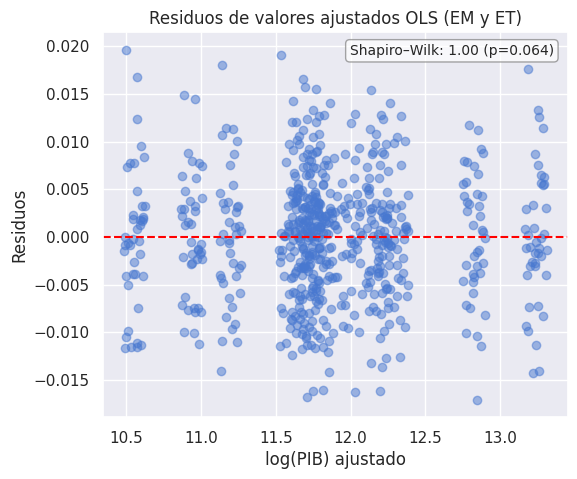

In [ ]:
residuals = model_geo_time.resid
plt.figure(figsize=(6,5))
plt.scatter(model_geo_time.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados OLS (EM y ET)")



stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"H0: Los residuos son normales")
print(f"Si p < 0.05 → Rechazamos normalidad")

plt.annotate(
    f"Shapiro–Wilk: {stat:.2f} (p={p_value:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.show()

In [ ]:
from scipy.stats import shapiro

residuals = model_geo_time.resid

stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"H0: Los residuos son normales")
print(f"Si p < 0.05 → Rechazamos normalidad")


Test de Shapiro-Wilk:
Estadístico: 0.9853
p-value: 0.000004
H0: Los residuos son normales
Si p < 0.05 → Rechazamos normalidad


In [ ]:
from scipy.stats import kruskal

# Agrupar por trimestre
groups = [quarterly_df_coded[quarterly_df_coded['quarter'] == q]['pib_mun'].values
          for q in [1, 2, 3, 4]]

stat, p_value = kruskal(*groups)
print(f"\nTest de Kruskal-Wallis:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Interpretación: p < 0.05 → Hay diferencias significativas entre trimestres (estacionalidad)")


Test de Kruskal-Wallis:
Estadístico: nan
p-value: nan
Interpretación: p < 0.05 → Hay diferencias significativas entre trimestres (estacionalidad)


/tmp/ipython-input-769686774.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = kruskal(*groups)
